In [31]:
import findspark
findspark.init()

In [32]:
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder. \
    appName("pyspark-1"). \
    getOrCreate()

### Read data

In [33]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True,inferSchema=True)
df.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

### clean data


In [34]:
def clean_and_normalize_df(df):

    for column in df.columns:
        df = df.withColumn(column, trim(col(column)))

    for column in df.columns:
        new_col = column.lower().replace(" ", "_").replace("/", "_")
        df = df.withColumnRenamed(column, new_col)

    df = (
        df.withColumn("salary_range_from", col("salary_range_from").cast(DoubleType()))
          .withColumn("salary_range_to", col("salary_range_to").cast(DoubleType()))
    )

    df = df.withColumn("salary_frequency", upper(col("salary_frequency")))

    df = df.withColumn(
        "posting_date",
        to_date(col("posting_date"), "yyyy-MM-dd")
    )

    df = df.withColumn(
        "salary_midpoint",
        (col("salary_range_from") + col("salary_range_to")) / 2
    )

    df = df.withColumn(
        "annual_salary",
        when(col("salary_frequency") == "HOURLY",
             col("salary_midpoint") * 2080)
        .when(col("salary_frequency") == "DAILY",
              col("salary_midpoint") * 260)
        .otherwise(col("salary_midpoint"))
    )

    df = df.filter(
        (col("annual_salary").isNotNull()) &
        (col("annual_salary") > 0)
    )

    if "job_id" in df.columns:
        df = df.dropDuplicates(["job_id"])
    else:
        df = df.dropDuplicates()

    return df

df_clean = clean_and_normalize_df(df)

df_clean.printSchema()
#df_clean.show(truncate = False)

root
 |-- job_id: string (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- #_of_positions: string (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full-time_part-time_indicator: string (nullable = true)
 |-- salary_range_from: double (nullable = true)
 |-- salary_range_to: double (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- additional_information: string (nullable = true)
 |-- to_apply: string (nullable = true)
 |-- hours_shift: string (nullable = true)
 |-- work_locatio

## KPIs


### 1.Whats the number of jobs posting per category (Top 10)?

In [35]:
kpi1 = (
    df_clean.groupBy("job_category")
            .count()
            .orderBy(col("count").desc())
            .limit(10)
)

kpi1.show(truncate=False)

+-----------------------------------------+-----+
|job_category                             |count|
+-----------------------------------------+-----+
|Engineering, Architecture, & Planning    |260  |
|Technology, Data & Innovation            |182  |
|Legal Affairs                            |120  |
|Building Operations & Maintenance        |99   |
|Finance, Accounting, & Procurement       |98   |
|Public Safety, Inspections, & Enforcement|98   |
|Administration & Human Resources         |88   |
|Health                                   |71   |
|Constituent Services & Community Programs|68   |
|Policy, Research & Analysis              |64   |
+-----------------------------------------+-----+



### Visualization — Top 10 Job Categories

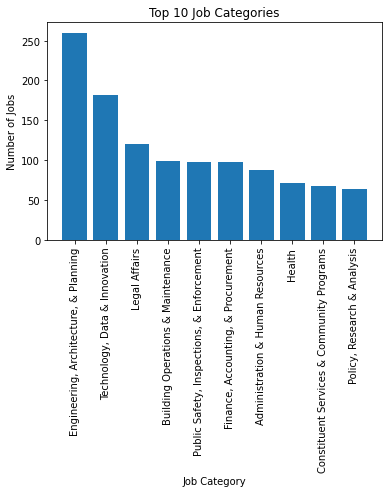

In [36]:
import matplotlib.pyplot as plt

pdf_kpi1 = kpi1.toPandas()

plt.figure()
plt.bar(pdf_kpi1["job_category"], pdf_kpi1["count"])
plt.xticks(rotation=90)
plt.title("Top 10 Job Categories")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.show()

### 2.Whats the salary distribution per job category?

In [37]:
kpi2 = (
    df_clean.groupBy("job_category")
            .agg(
                avg("annual_salary").alias("avg_salary"),
                min("annual_salary").alias("min_salary"),
                max("annual_salary").alias("max_salary")
            )
            .orderBy(col("avg_salary").desc())
)

kpi2.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+------------------+------------------+
|job_category                                                                                                                                                                                             |avg_salary        |min_salary        |max_salary        |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+------------------+------------------+
|Administration & Human Resources Finance, Accounting, & Procurement Building Operations & Maintenance                                                                                                    |218587.0      

### 3. Is there any correlation between the higher degree and the salary?

In [38]:
df_degree = df_clean.withColumn(
    "degree_level",
    when(col("minimum_qual_requirements").rlike("PhD|Doctor"), 3)
    .when(col("minimum_qual_requirements").rlike("Master"), 2)
    .when(col("minimum_qual_requirements").rlike("Bachelor"), 1)
    .otherwise(0)
)

correlation = df_degree.stat.corr("degree_level", "annual_salary")

print("Correlation:", correlation)

has_positive_correlation = correlation is not None and correlation > 0

print("Is there positive correlation between degree and salary? ->",
      "Yes" if has_positive_correlation else "No")

Correlation: 0.06428680045265771
Is there positive correlation between degree and salary? -> Yes


### 4.Whats the job posting having the highest salary per agency?



In [39]:
kpi4 = (
    df_clean.groupBy("agency")
            .agg(max("annual_salary").alias("highest_salary"))
            .orderBy(col("highest_salary").desc())
)

kpi4.show(truncate=False)

+------------------------------+------------------+
|agency                        |highest_salary    |
+------------------------------+------------------+
|DEPT OF ENVIRONMENT PROTECTION|218587.0          |
|POLICE DEPARTMENT             |217201.0          |
|DISTRICT ATTORNEY KINGS COUNTY|191913.0          |
|NYC HOUSING AUTHORITY         |180000.0          |
|NYC EMPLOYEES RETIREMENT SYS  |177374.5          |
|DEPT OF HEALTH/MENTAL HYGIENE |170133.84         |
|OFFICE OF THE COMPTROLLER     |167500.0          |
|DEPARTMENT OF INVESTIGATION   |165000.0          |
|LAW DEPARTMENT                |164104.0          |
|DEPARTMENT OF SANITATION      |158038.4          |
|DEPT OF DESIGN & CONSTRUCTION |151795.0          |
|DEPARTMENT FOR THE AGING      |150371.0          |
|DEPT OF CITYWIDE ADMIN SVCS   |140171.2          |
|TAXI & LIMOUSINE COMMISSION   |140000.0          |
|DEPARTMENT OF CORRECTION      |139105.09600000002|
|DEPT OF INFO TECH & TELECOMM  |138968.0          |
|FINANCIAL I

### 5.Whats the job positings average salary per agency for the last 2 years?

In [40]:
latest_year = (
    df_clean
    .filter(col("posting_date").isNotNull())
    .select(year(col("posting_date")).alias("year"))
    .agg(max("year"))
    .collect()[0][0]
)

kpi5 = (
    df_clean.filter(year(col("posting_date")) >= latest_year - 2)
            .groupBy("agency")
            .agg(avg("annual_salary").alias("avg_salary"))
            .orderBy(col("avg_salary").desc())
)

kpi5.show(truncate=False)

+------------------------------+------------------+
|agency                        |avg_salary        |
+------------------------------+------------------+
|CONFLICTS OF INTEREST BOARD   |135000.0          |
|FIRE DEPARTMENT               |108140.93333333333|
|BUSINESS INTEGRITY COMMISSION |95000.0           |
|FINANCIAL INFO SVCS AGENCY    |93994.5           |
|DEPARTMENT OF SANITATION      |90029.70999999999 |
|DEPT OF INFO TECH & TELECOMM  |88313.03448275862 |
|MAYORS OFFICE OF CONTRACT SVCS|87357.14285714286 |
|OFFICE OF THE COMPTROLLER     |85235.71428571429 |
|HOUSING PRESERVATION & DVLPMNT|84882.17857142857 |
|CONSUMER AFFAIRS              |82550.66666666667 |
|PRESIDENT BOROUGH OF MANHATTAN|82500.0           |
|HUMAN RIGHTS COMMISSION       |82444.9485        |
|DEPT OF YOUTH & COMM DEV SRVS |80697.875         |
|DEPT OF CITYWIDE ADMIN SVCS   |79921.2888888889  |
|DEPARTMENT OF PROBATION       |79175.64          |
|LAW DEPARTMENT                |79054.03726829268 |
|NYC HOUSING

### 6.What are the highest paid skills in the US market?

In [41]:
df_skills = df_clean.withColumn(
    "skill",
    explode(split(col("preferred_skills"), ","))
)

kpi6 = (
    df_skills.groupBy("skill")
             .agg(avg("annual_salary").alias("avg_salary"))
             .orderBy(col("avg_salary").desc())
)

kpi6.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|skill                                                                                                                                                                                                                                                                                        |avg_salary|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
| of which at least 3 years must have been in a senior leadership position â€¢	BA/BS degree; MBA/advanc

### Saving Cleaned Dataset

In [42]:
df_clean.write.mode("overwrite").parquet("processed_nyc_jobs")